# Анализ покупательской активности магазина "В один клик"

**Описание:**

Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.
«В один клик» — современная компания, поэтому её руководство не хочет принимать решения просто так — только на основе анализа данных и бизнес-моделирования. У компании есть небольшой отдел цифровых технологий, и вам предстоит побыть в роли стажёра в этом отделе. 
Итак, вашему отделу поручили разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

**Цель проекта:**

    1. Нужно промаркировать уровень финансовой активности постоянных покупателей. В компании принято выделять два уровня активности: «снизилась», если клиент стал покупать меньше товаров, и «прежний уровень».
    2. Нужно собрать данные по клиентам по следующим группам: 
        ◦ Признаки, которые описывают коммуникацию сотрудников компании с клиентом.
        ◦ Признаки, которые описывают продуктовое поведение покупателя. Например, какие товары покупает и как часто.
        ◦ Признаки, которые описывают покупательское поведение клиента. Например, сколько тратил в магазине.
        ◦ Признаки, которые описывают поведение покупателя на сайте. Например, как много страниц просматривает и сколько времени проводит на сайте.
    3. Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.
    4. В исследование нужно включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца.
    5. Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.

**Данные для работы:**

1. market_file.csv
Таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.
- id — номер покупателя в корпоративной базе данных.
- Покупательская активность — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
- Тип сервиса — уровень сервиса, например «премиум» и «стандарт».
- Разрешить сообщать — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
- Маркет_актив_6_мес — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
- Маркет_актив_тек_мес — количество маркетинговых коммуникаций в текущем месяце.
- Длительность — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
- Акционные_покупки — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
- Популярная_категория — самая популярная категория товаров у покупателя за последние 6 месяцев.
- Средний_просмотр_категорий_за_визит — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
- Неоплаченные_продукты_штук_квартал — общее число неоплаченных товаров в корзине за последние 3 месяца.
- Ошибка_сервиса — число сбоев, которые коснулись покупателя во время посещения сайта.
- Страниц_за_визит — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.
2. market_money.csv
Таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.
- id — номер покупателя в корпоративной базе данных.
- Период — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц'.
- Выручка — сумма выручки за период.
3. market_time.csv
Таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.
- id — номер покупателя в корпоративной базе данных.
- Период — название периода, во время которого зафиксировано общее время.
- минут — значение времени, проведённого на сайте, в минутах.
4. money.csv
Таблица с данными о среднемесячной прибыли покупателя за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.
- id — номер покупателя в корпоративной базе данных.
- Прибыль — значение прибыли.

In [1]:
!pip install -U scikit-learn -q

In [2]:
pip install phik -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install shap -q

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import roc_auc_score, f1_score, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix

import shap
import time

RANDOM_STATE = 38
TEST_SIZE = 0.25

## Загрузка данных

In [5]:
df_main = pd.read_csv('https://code.s3.yandex.net/datasets/market_file.csv')
df_main.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [6]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [7]:
df_market_money = pd.read_csv('https://code.s3.yandex.net/datasets/market_money.csv')
df_market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [8]:
df_market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [9]:
df_market_time = pd.read_csv('https://code.s3.yandex.net/datasets/market_time.csv')
df_market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [10]:
df_market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [11]:
df_money = pd.read_csv('https://code.s3.yandex.net/datasets/money.csv', sep=';', decimal=',')
df_money.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


In [12]:
df_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Данные загружены в датафреймы. Данные в файлах есть и соответствуют предоставленной информации. Пропусков нет. Можно перейти к предобработке данных.

## Предобработка данных

In [13]:
df_main.duplicated().sum()

0

In [14]:
df_market_money.duplicated().sum()

0

In [15]:
df_market_time.duplicated().sum()

0

In [16]:
df_money.duplicated().sum()

0

In [17]:
df_main.set_index('id', inplace=True)
df_market_money.set_index('id', inplace=True)
df_market_time.set_index('id', inplace=True)
df_money.set_index('id', inplace=True)

In [18]:
df_main.columns = df_main.columns.str.replace(' ', '_')
df_main.columns = df_main.columns.str.lower()
df_main.columns

Index(['покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит'],
      dtype='object')

In [19]:
df_main['покупательская_активность'].unique()

array(['Снизилась', 'Прежний уровень'], dtype=object)

In [20]:
df_main['покупательская_активность'] = df_main['покупательская_активность'].str.replace(' ', '_')
df_main['покупательская_активность'] = df_main['покупательская_активность'].str.lower()
df_main['покупательская_активность'].unique()

array(['снизилась', 'прежний_уровень'], dtype=object)

In [21]:
df_main['тип_сервиса'].unique()

array(['премиум', 'стандартт', 'стандарт'], dtype=object)

In [22]:
df_main['тип_сервиса'] = df_main['тип_сервиса'].str.replace('стандартт', 'стандарт')
df_main['тип_сервиса'].unique()

array(['премиум', 'стандарт'], dtype=object)

In [23]:
df_main['разрешить_сообщать'].unique()

array(['да', 'нет'], dtype=object)

In [24]:
df_main['популярная_категория'].unique()

array(['Товары для детей', 'Домашний текстиль', 'Косметика и аксесуары',
       'Техника для красоты и здоровья', 'Кухонная посуда',
       'Мелкая бытовая техника и электроника'], dtype=object)

In [25]:
df_main['популярная_категория'] = df_main['популярная_категория'].str.replace(' ', '_')
df_main['популярная_категория'] = df_main['популярная_категория'].str.lower()
df_main['популярная_категория'].unique()

array(['товары_для_детей', 'домашний_текстиль', 'косметика_и_аксесуары',
       'техника_для_красоты_и_здоровья', 'кухонная_посуда',
       'мелкая_бытовая_техника_и_электроника'], dtype=object)

In [26]:
df_market_money.columns = df_market_money.columns.str.lower()

In [27]:
df_market_money['период'].unique()

array(['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц'],
      dtype=object)

In [28]:
df_market_time.columns = df_market_time.columns.str.lower()

In [29]:
df_market_time['период'].unique()

array(['текущий_месяц', 'предыдцщий_месяц'], dtype=object)

In [30]:
df_market_time['период'] = df_market_time['период'].str.replace('предыдцщий', 'предыдущий')
df_market_time['период'].unique()

array(['текущий_месяц', 'предыдущий_месяц'], dtype=object)

В данных не было явных дубликатов. Были устранены неявные дубликаты. Названия столбцов и строковые значения параметров были приведены к змеиному стилю. Была исправлена опечатка в значении 'предыдцщий_месяц'. В качестве индексов были использованы колонки id. Можно приступить к исследованию данных.

## Исследовательский анализ данных

In [31]:
df_main.describe()

,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


In [32]:
def plot_box_hist(param, param_name, df, hue):
    #построение ящика с усами
    plt.figure(figsize = (10.5, 2))
    plot_box = sns.boxplot(x=param)
    plt.title(f'Разброс значений параметра {param_name}')
    plt.show()
    #построение гистограммы
    plt.figure(figsize = (10, 6))
    plt.axvline(param.mean(), c='red', ls='-', lw=2.5, label='Среднее')
    plt.axvline(param.median(), c='green', ls='--', lw=2.5, label='Медиана')
    plt.legend(loc='upper left')
    plot_hist = sns.histplot(data=df, x=param, hue=hue)
    plt.title(f'Распределение значений параметра {param_name}')
    plt.xlabel(f'{param_name}')
    plt.ylabel('Количество')
    plt.grid(axis='y')
    plt.show()
    return plot_box, plot_hist

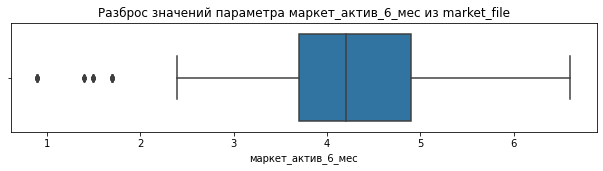

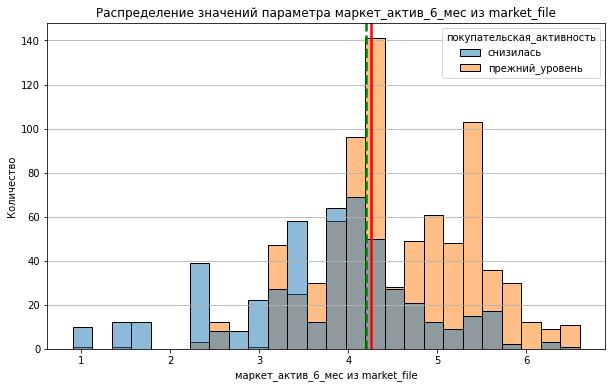

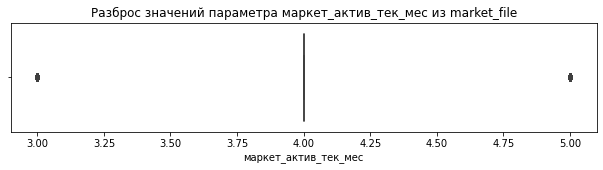

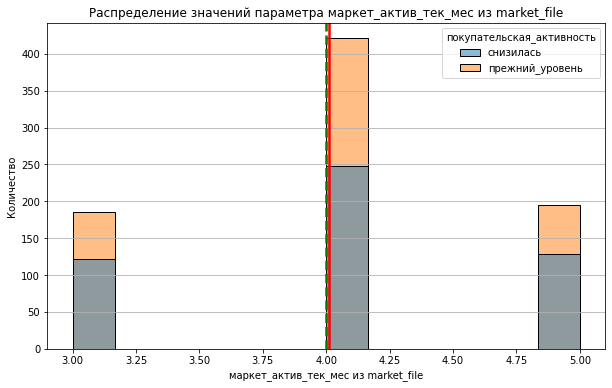

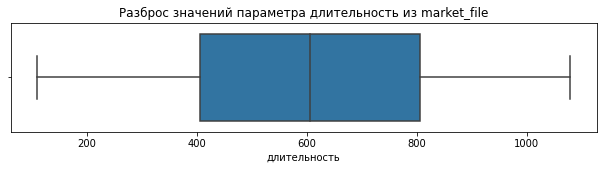

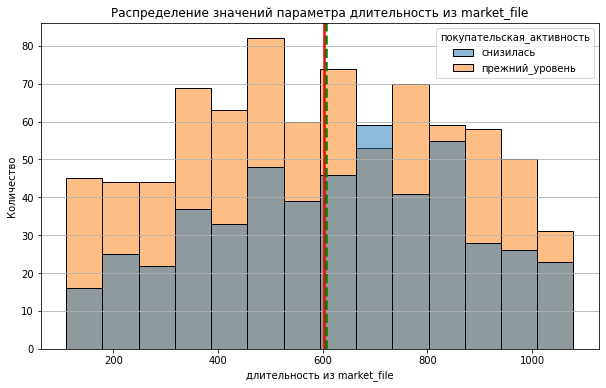

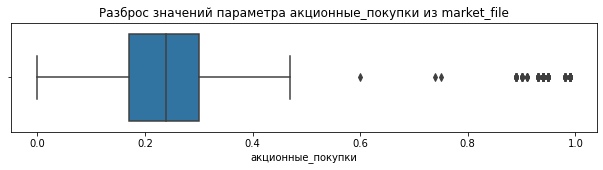

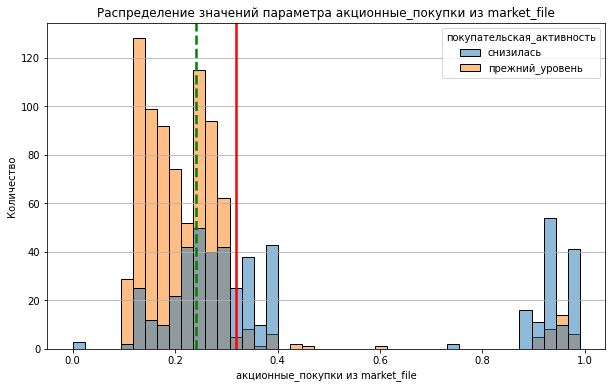

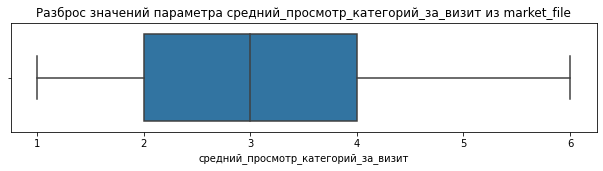

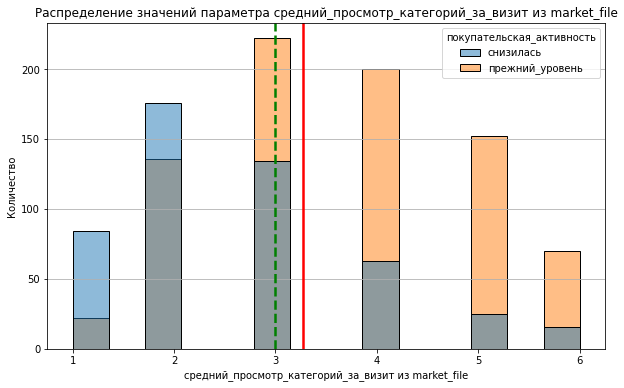

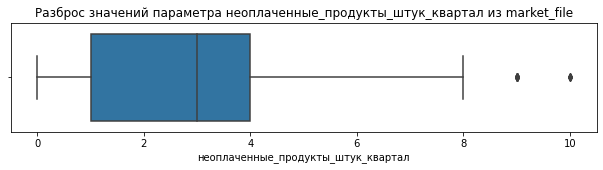

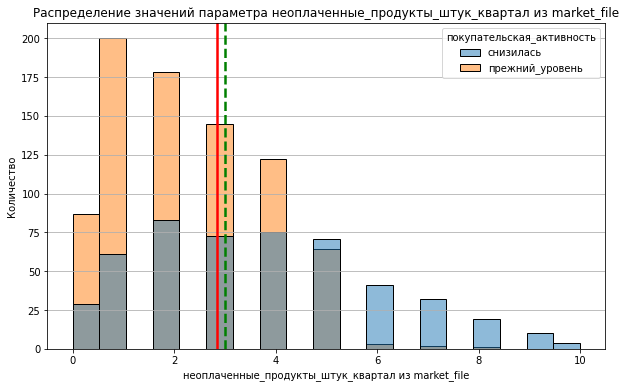

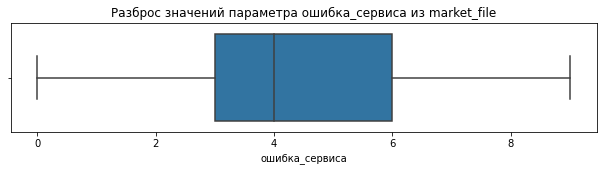

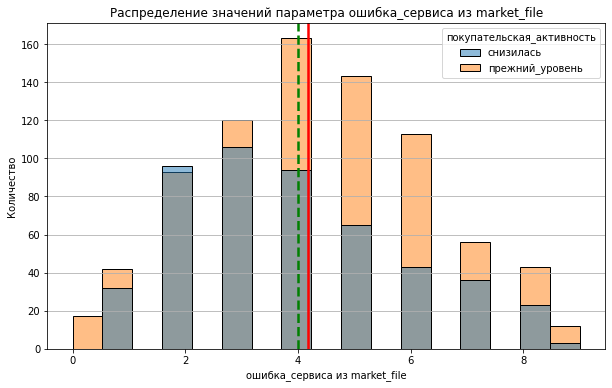

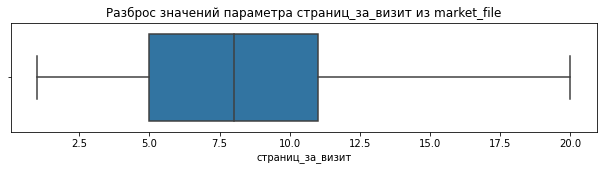

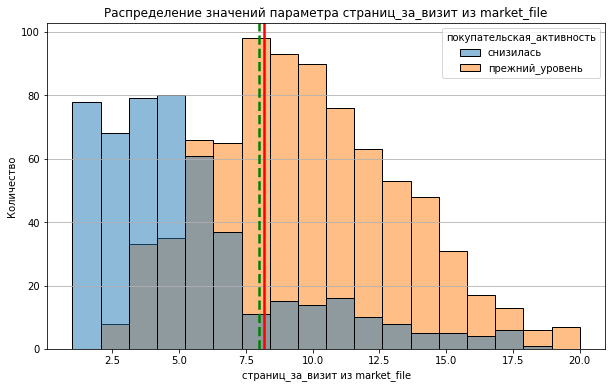

In [33]:
for column in df_main.select_dtypes(include='number').columns.tolist():
    plot_box_hist(df_main[column], f'{column} из market_file', df_main, 'покупательская_активность')

Параметр "акционные покупки" не имеет нормального распределения значений, есть много выбросов.

 Значения параметра покупательская_активность:
прежний_уровень    802
снизилась          498
Name: покупательская_активность, dtype: int64


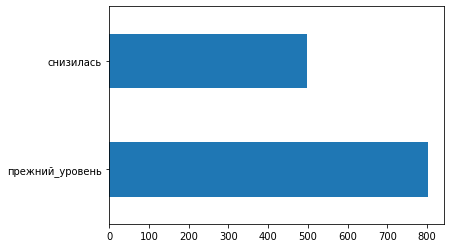

 Значения параметра тип_сервиса:
стандарт    924
премиум     376
Name: тип_сервиса, dtype: int64


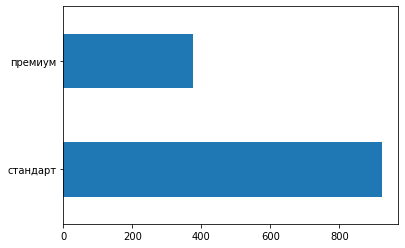

 Значения параметра разрешить_сообщать:
да     962
нет    338
Name: разрешить_сообщать, dtype: int64


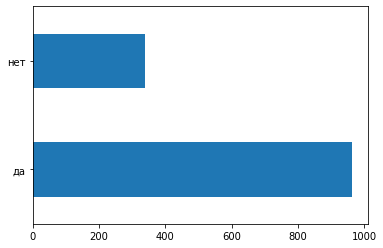

 Значения параметра популярная_категория:
товары_для_детей                        330
домашний_текстиль                       251
косметика_и_аксесуары                   223
техника_для_красоты_и_здоровья          184
мелкая_бытовая_техника_и_электроника    174
кухонная_посуда                         138
Name: популярная_категория, dtype: int64


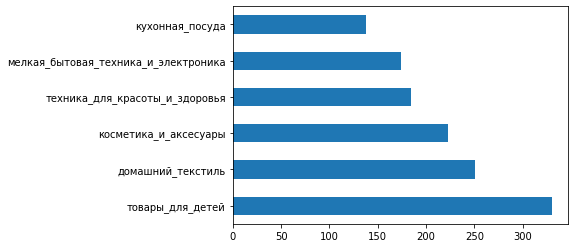

In [34]:
for column in df_main.select_dtypes(exclude='number').columns.tolist():
    print(f' Значения параметра {column}:')
    print(df_main[column].value_counts())
#    sns.barplot(df_main[column].value_counts(), hue=column)
    df_main[column].value_counts().plot.barh()
    plt.show()

In [35]:
market_money_pivot = df_market_money.pivot_table(index=df_market_money.index,
                                                 columns='период',
                                                 values='выручка',
                                                 aggfunc='sum')
market_money_pivot[(market_money_pivot['препредыдущий_месяц'] > 0) 
                   & (market_money_pivot['предыдущий_месяц'] > 0)
                   & (market_money_pivot['текущий_месяц'] > 0)
                  ]

период,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
id,,,
215349,5216.0,4472.0,4971.6
215350,5457.5,4826.0,5058.4
215351,6158.0,4793.0,6610.4
215352,5807.5,4594.0,5872.5
215353,4738.5,5124.0,5388.5
...,...,...,...
216643,3664.0,4704.0,4741.7
216644,4729.0,5299.0,5353.0
216645,5160.0,5334.0,5139.2


In [36]:
market_money_pivot = market_money_pivot[(market_money_pivot['препредыдущий_месяц'] > 0)
                                        & (market_money_pivot['предыдущий_месяц'] > 0)
                                        & (market_money_pivot['текущий_месяц'] > 0)]

Почти все клиенты (1297 из 1300) имеют покупательскую активностью не менее трёх месяцев (которые что-либо покупали в этот период)

In [37]:
market_money_pivot.describe()

период,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
count,1297.000000,1297.000000,1297.000000
mean,4948.339630,4836.367772,5316.449268
std,701.228571,333.438742,2942.469139
min,2890.000000,4098.000000,2758.700000
25%,4498.500000,4585.000000,4706.600000
50%,5005.500000,4812.000000,5180.300000
75%,5409.000000,5055.000000,5761.300000
max,6869.500000,5663.000000,106862.200000


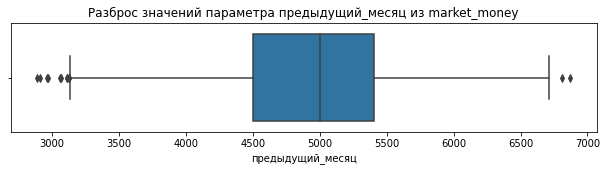

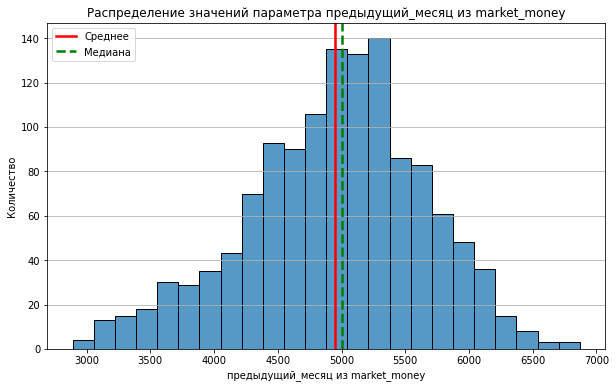

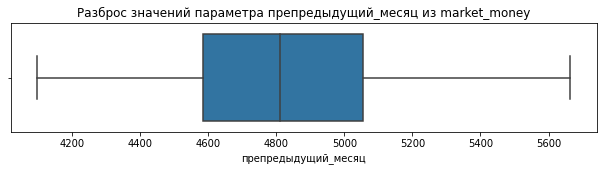

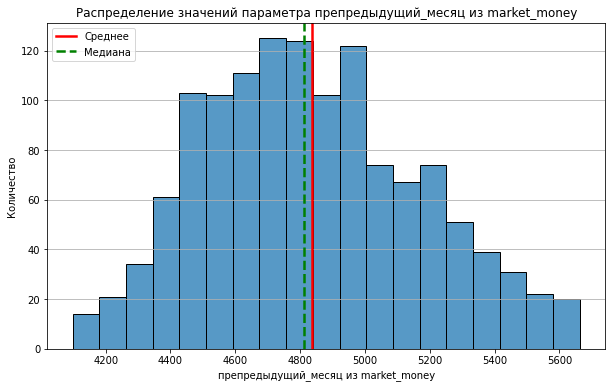

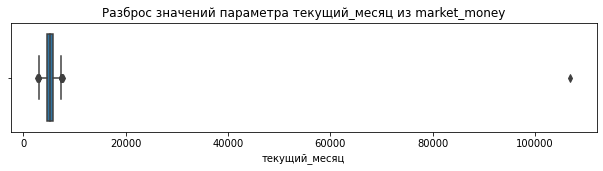

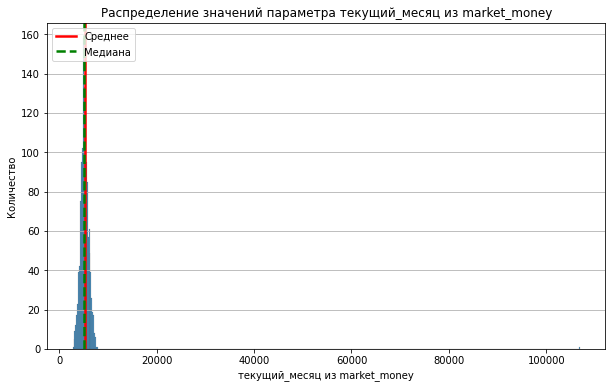

In [38]:
for column in market_money_pivot.columns.tolist():
    plot_box_hist(market_money_pivot[column], f'{column} из market_money', None, None)

In [39]:
market_money_pivot[market_money_pivot['текущий_месяц'] > 20000]

период,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
id,,,
215380,6077.0,5051.0,106862.2


Значение выручки для пользователя с id=215380 за текущий месяц аномально высокое. Замень аномалию средним значением выручки данного пользователя, оно не сильно отличается от среднего всей выборки.

In [40]:
df_market_money.loc[((df_market_money.index == 215380)
                    & (df_market_money['период'] == 'текущий_месяц')),
                    'выручка'] = (df_market_money[(df_market_money.index == 215380)
                                                  & (df_market_money['период'] == 'препредыдущий_месяц')]['выручка']
                                  + df_market_money[(df_market_money.index == 215380)
                                                    & (df_market_money['период'] == 'предыдущий_месяц')]['выручка']) / 2 
market_money_pivot = df_market_money.pivot_table(index=df_market_money.index,
                                                 columns='период',
                                                 values='выручка',
                                                 aggfunc='sum')

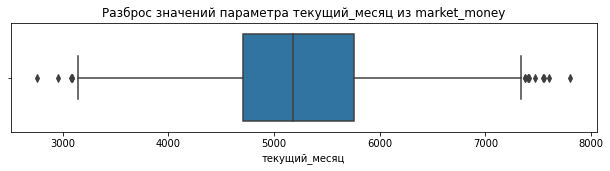

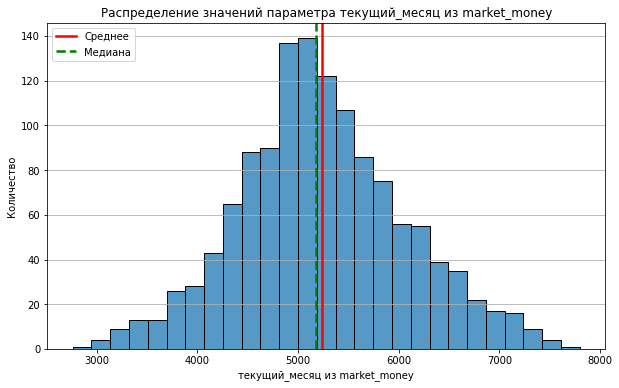

In [41]:
plot_box_hist(market_money_pivot['текущий_месяц'], 'текущий_месяц из market_money', None, None);

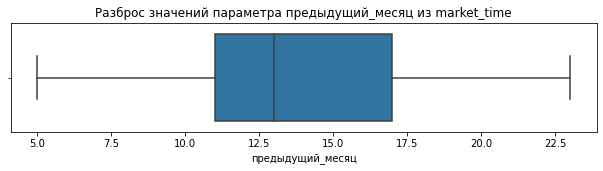

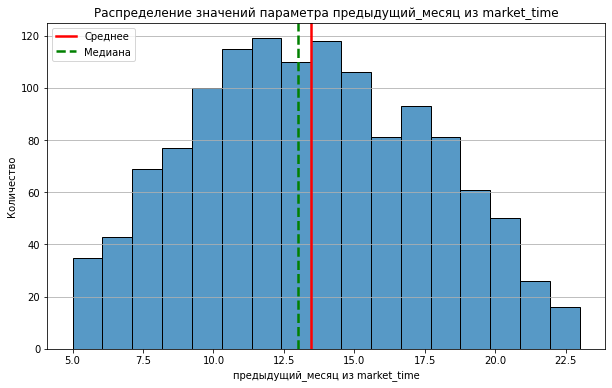

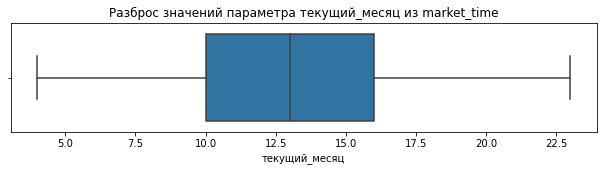

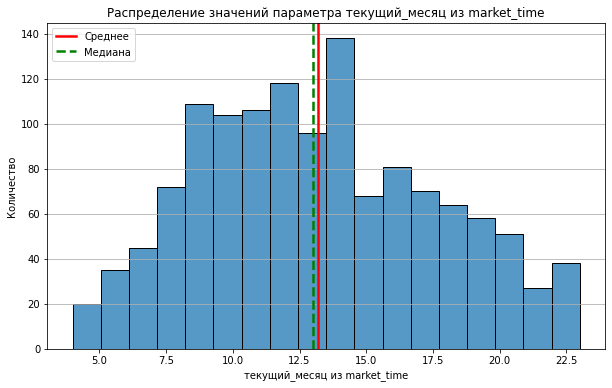

In [42]:
market_time_pivot = df_market_time.pivot_table(index=df_market_time.index,
                                               columns='период',
                                               values='минут',
                                               aggfunc='sum')
for column in market_time_pivot.columns.tolist():
    plot_box_hist(market_time_pivot[column], f'{column} из market_time', None, None)

Выполнен обзор данных, устранена аномалия в значении выручки. Почти все клиенты выборки (за исключением 3) имеют активность все 3 месяца.

## Объединение таблиц

In [43]:
df_main = df_main.join(df_market_money[df_market_money['период'] == 'препредыдущий_месяц']['выручка'])
df_main = df_main.join(df_market_money[df_market_money['период'] == 'предыдущий_месяц']['выручка'], rsuffix='_предыдущий_месяц')
df_main = df_main.join(df_market_money[df_market_money['период'] == 'текущий_месяц']['выручка'], rsuffix='_текущий_месяц')
df_main.columns = df_main.columns.str.replace('выручка$', 'выручка_препредыдущий_месяц', regex=True)
df_main.head()

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_препредыдущий_месяц,выручка_предыдущий_месяц,выручка_текущий_месяц
id,,,,,,,,,,,,,,,
215348,снизилась,премиум,да,3.4,5,121,0.00,товары_для_детей,6,2,1,5,0.0,0.0,3293.1
215349,снизилась,премиум,да,4.4,4,819,0.75,товары_для_детей,4,4,2,5,4472.0,5216.0,4971.6
215350,снизилась,стандарт,нет,4.9,3,539,0.14,домашний_текстиль,5,2,1,5,4826.0,5457.5,5058.4
215351,снизилась,стандарт,да,3.2,5,896,0.99,товары_для_детей,5,0,6,4,4793.0,6158.0,6610.4
215352,снизилась,стандарт,нет,5.1,3,1064,0.94,товары_для_детей,3,2,3,2,4594.0,5807.5,5872.5


In [44]:
df_main = df_main.join(df_market_time[df_market_time['период'] == 'предыдущий_месяц']['минут'])
df_main = df_main.join(df_market_time[df_market_time['период'] == 'текущий_месяц']['минут'], rsuffix='_текущий_месяц')
df_main.columns = df_main.columns.str.replace('минут$', 'минут_предыдущий_месяц', regex=True)
df_main.head()

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_препредыдущий_месяц,выручка_предыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
id,,,,,,,,,,,,,,,,,
215348,снизилась,премиум,да,3.4,5,121,0.00,товары_для_детей,6,2,1,5,0.0,0.0,3293.1,13,14
215349,снизилась,премиум,да,4.4,4,819,0.75,товары_для_детей,4,4,2,5,4472.0,5216.0,4971.6,12,10
215350,снизилась,стандарт,нет,4.9,3,539,0.14,домашний_текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13
215351,снизилась,стандарт,да,3.2,5,896,0.99,товары_для_детей,5,0,6,4,4793.0,6158.0,6610.4,11,13
215352,снизилась,стандарт,нет,5.1,3,1064,0.94,товары_для_детей,3,2,3,2,4594.0,5807.5,5872.5,8,11


In [45]:
df_main = df_main[(df_main['выручка_препредыдущий_месяц'] > 0)
                  & (df_main['выручка_предыдущий_месяц'] > 0)
                  & (df_main['выручка_текущий_месяц'] > 0)]

In [46]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1297 entries, 215349 to 216647
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   покупательская_активность            1297 non-null   object 
 1   тип_сервиса                          1297 non-null   object 
 2   разрешить_сообщать                   1297 non-null   object 
 3   маркет_актив_6_мес                   1297 non-null   float64
 4   маркет_актив_тек_мес                 1297 non-null   int64  
 5   длительность                         1297 non-null   int64  
 6   акционные_покупки                    1297 non-null   float64
 7   популярная_категория                 1297 non-null   object 
 8   средний_просмотр_категорий_за_визит  1297 non-null   int64  
 9   неоплаченные_продукты_штук_квартал   1297 non-null   int64  
 10  ошибка_сервиса                       1297 non-null   int64  
 11  страниц_за_визит       

Данные из датафреймов market_money и market_time с информацией по выручке и времени на сайте были добавлены в основной датафрейм df_main (в однельные колонки для каждого периода). Пропуска в данных нет. Для дальнейшей работы над данными остались тольк клиенты с покупательской октивностью не менее 3 месяцев.

## Корреляционный анализ

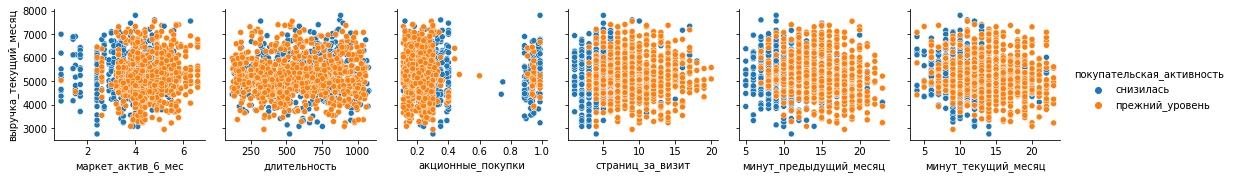

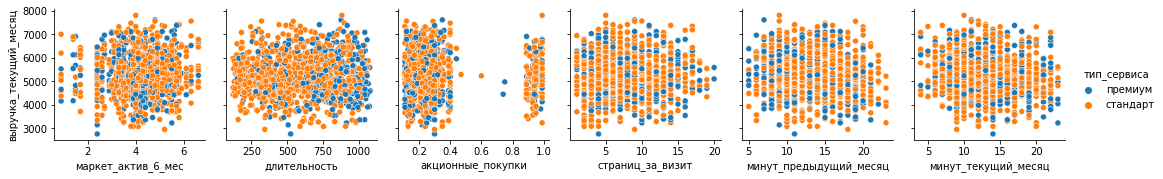

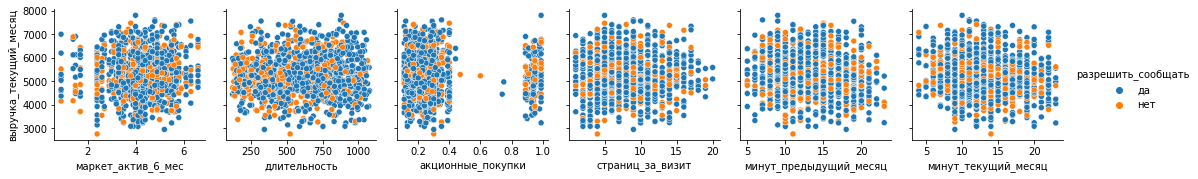

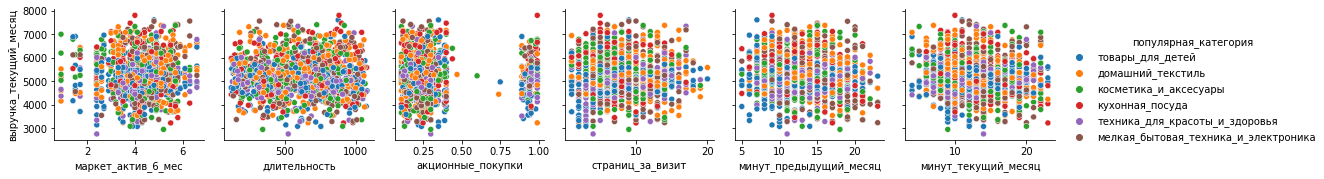

In [47]:
cat = df_main.select_dtypes(exclude='number').columns.tolist()
factor = ['маркет_актив_6_мес', 'длительность',
          'акционные_покупки', 'страниц_за_визит',
          'минут_предыдущий_месяц', 'минут_текущий_месяц']
for category in cat:
    g = sns.PairGrid(df_main, hue=category, x_vars=factor, y_vars='выручка_текущий_месяц')
    g.map(sns.scatterplot)
    g.add_legend()

In [48]:
df_main.columns

Index(['покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит', 'выручка_препредыдущий_месяц',
       'выручка_предыдущий_месяц', 'выручка_текущий_месяц',
       'минут_предыдущий_месяц', 'минут_текущий_месяц'],
      dtype='object')

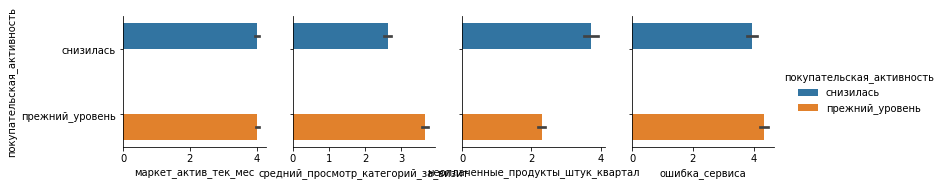

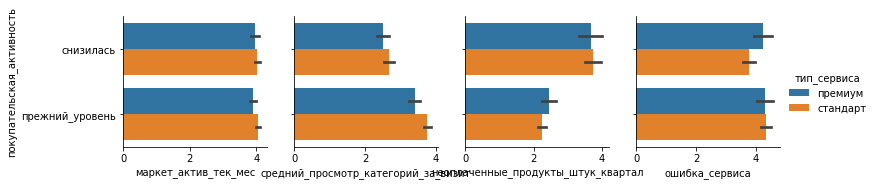

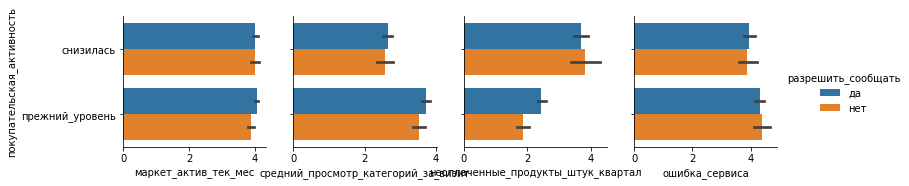

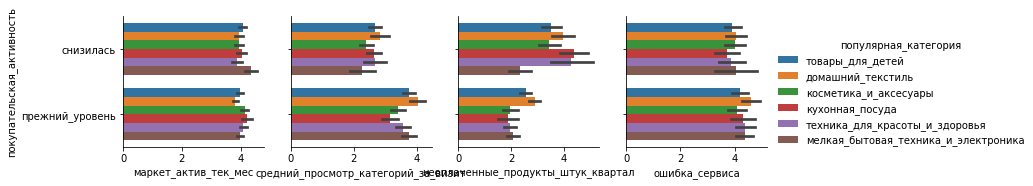

In [49]:
factor = ['маркет_актив_тек_мес', 'средний_просмотр_категорий_за_визит',
          'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса']
for category in cat:
    g = sns.PairGrid(df_main, hue=category, x_vars=factor, y_vars='покупательская_активность')
    g.map(sns.barplot)
    g.add_legend()

In [50]:
df_main.phik_matrix()

interval columns not set, guessing: ['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит', 'выручка_препредыдущий_месяц', 'выручка_предыдущий_месяц', 'выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц']


,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_препредыдущий_месяц,выручка_предыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
покупательская_активность,1.000000,0.132247,0.000000,0.546370,0.000000,0.101767,0.506991,0.298036,0.539221,0.504845,0.223697,0.748769,0.495174,0.227280,0.196561,0.685078,0.575662
тип_сервиса,0.132247,1.000000,0.286278,0.094182,0.044796,0.401158,0.033339,0.066285,0.186635,0.120842,0.076182,0.100832,0.068507,0.000000,0.121554,0.131084,0.000000
разрешить_сообщать,0.000000,0.286278,1.000000,0.000000,0.051971,0.253956,0.017252,0.071769,0.069322,0.195442,0.020464,0.041128,0.000000,0.079830,0.062568,0.042350,0.000000
маркет_актив_6_мес,0.546370,0.094182,0.000000,1.000000,0.080454,0.000000,0.278729,0.149812,0.205783,0.286304,0.147270,0.394108,0.312243,0.149129,0.024850,0.363780,0.328385
маркет_актив_тек_мес,0.000000,0.044796,0.051971,0.080454,1.000000,0.174385,0.000000,0.136175,0.246726,0.143827,0.116310,0.000000,0.000000,0.054683,0.000000,0.106879,0.062485
длительность,0.101767,0.401158,0.253956,0.000000,0.174385,1.000000,0.000000,0.000000,0.187774,0.191923,0.174467,0.122727,0.114058,0.125303,0.147306,0.024075,0.100502
акционные_покупки,0.506991,0.033339,0.017252,0.278729,0.000000,0.000000,1.000000,0.122840,0.199417,0.237583,0.000000,0.310741,0.225681,0.065412,0.072241,0.262189,0.250014
популярная_категория,0.298036,0.066285,0.071769,0.149812,0.136175,0.000000,0.122840,1.000000,0.225622,0.248558,0.000000,0.160623,0.045814,0.250974,0.236739,0.195219,0.089923
средний_просмотр_категорий_за_визит,0.539221,0.186635,0.069322,0.205783,0.246726,0.187774,0.199417,0.225622,1.000000,0.325688,0.069908,0.262610,0.176770,0.100332,0.092944,0.159393,0.182708
неоплаченные_продукты_штук_квартал,0.504845,0.120842,0.195442,0.286304,0.143827,0.191923,0.237583,0.248558,0.325688,1.000000,0.033392,0.363879,0.261530,0.249471,0.229691,0.255982,0.232121


In [52]:
df_final = df_main.copy()
df_for_vif = df_main.copy()
df_for_vif['покупательская_активность'] = df_for_vif['покупательская_активность'].map({'прежний_уровень':0, 'снизилась':1})
df_for_vif['тип_сервиса'] = df_for_vif['тип_сервиса'].map({'стандарт':0, 'премиум':1})
df_for_vif['разрешить_сообщать'] = df_for_vif['разрешить_сообщать'].map({'нет':0, 'да':1})
df_for_vif['популярная_категория'] = df_for_vif['популярная_категория'].map({'товары_для_детей':0,
                                                                             'домашний_текстиль':1, 
                                                                             'косметика_и_аксесуары':2, 
                                                                             'кухонная_посуда':3, 
                                                                             'техника_для_красоты_и_здоровья':4, 
                                                                             'мелкая_бытовая_техника_и_электроника':5})
df_for_vif.sample(3)

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_препредыдущий_месяц,выручка_предыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
id,,,,,,,,,,,,,,,,,
215607,1,1,1,3.0,3,862,0.94,2,1,5,2,8,4313.0,4397.0,4922.2,9,11
215802,1,0,1,3.4,4,698,0.16,3,4,3,4,11,5154.0,4955.0,5257.9,11,20
215877,0,0,1,4.1,4,349,0.17,5,6,5,4,9,4665.0,4324.5,4159.4,16,19


In [53]:
vif_data = pd.DataFrame()
vif_data['признак'] = df_for_vif.columns

vif_data['VIF'] = [variance_inflation_factor(df_for_vif.values, i)
                   for i in range(len(df_for_vif.columns))]
print('Значение Variance Inflation Factor для каждого признака:')
vif_data.sort_values('VIF', ascending=False)

Значение Variance Inflation Factor для каждого признака:


,признак,VIF
13,выручка_предыдущий_месяц,210.892064
12,выручка_препредыдущий_месяц,153.730657
14,выручка_текущий_месяц,147.253670
4,маркет_актив_тек_мес,32.144190
3,маркет_актив_6_мес,23.065930
15,минут_предыдущий_месяц,20.673517
16,минут_текущий_месяц,14.838707
8,средний_просмотр_категорий_за_визит,8.252618
5,длительность,8.227388
11,страниц_за_визит,8.044309


Высокие значения VIF для признаков выручки, а так же маркетинговых коммуникаций, свидетельствуют о сильной мультиколлинеарности между этими переменными

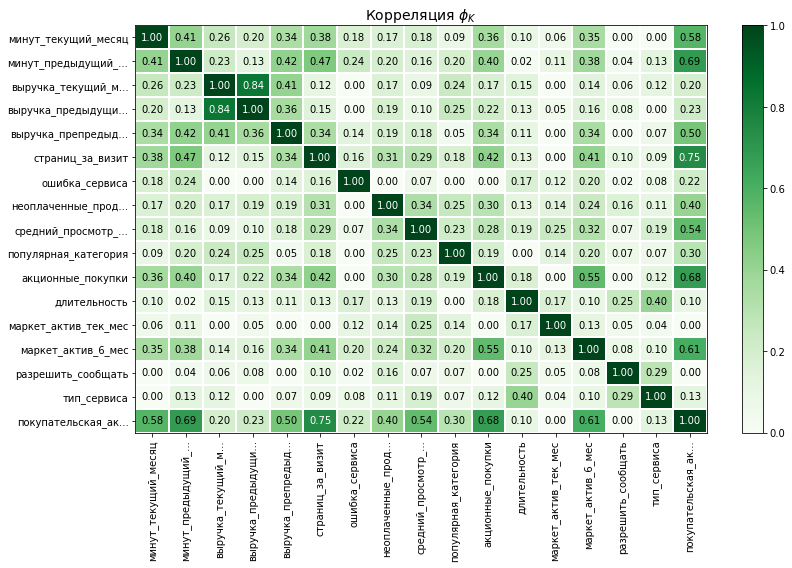

In [54]:
interval_cols = ['длительность',
                 'выручка_препредыдущий_месяц', 'выручка_предыдущий_месяц', 'выручка_текущий_месяц',
                 'минут_предыдущий_месяц', 'минут_текущий_месяц']
phik_overview = phik_matrix(df_main, interval_cols=interval_cols)
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'Корреляция $\phi_K$',
    fontsize_factor=1.0,
    figsize=(12, 8)
) 

In [55]:
df_final['выручка_пред_минус_предпред'] = df_final['выручка_предыдущий_месяц'] - df_final['выручка_препредыдущий_месяц']
df_final['выручка_текущий_минус_пред'] = df_final['выручка_текущий_месяц'] - df_final['выручка_предыдущий_месяц']
df_final['выручка_квартал'] = (df_final['выручка_текущий_месяц']
                               + df_final['выручка_предыдущий_месяц']
                               + df_final['выручка_препредыдущий_месяц']) / 3
df_final = df_final.drop(['тип_сервиса', 'разрешить_сообщать',
                          'маркет_актив_тек_мес', 'длительность'], axis=1)
df_final.head()

,покупательская_активность,маркет_актив_6_мес,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_препредыдущий_месяц,выручка_предыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,выручка_пред_минус_предпред,выручка_текущий_минус_пред,выручка_квартал
id,,,,,,,,,,,,,,,,
215349,снизилась,4.4,0.75,товары_для_детей,4,4,2,5,4472.0,5216.0,4971.6,12,10,744.0,-244.4,4886.533333
215350,снизилась,4.9,0.14,домашний_текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13,631.5,-399.1,5113.966667
215351,снизилась,3.2,0.99,товары_для_детей,5,0,6,4,4793.0,6158.0,6610.4,11,13,1365.0,452.4,5853.800000
215352,снизилась,5.1,0.94,товары_для_детей,3,2,3,2,4594.0,5807.5,5872.5,8,11,1213.5,65.0,5424.666667
215353,снизилась,3.3,0.26,домашний_текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10,-385.5,650.0,5083.666667


interval columns not set, guessing: ['маркет_актив_6_мес', 'акционные_покупки', 'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит', 'выручка_препредыдущий_месяц', 'выручка_предыдущий_месяц', 'выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц', 'выручка_пред_минус_предпред', 'выручка_текущий_минус_пред', 'выручка_квартал']


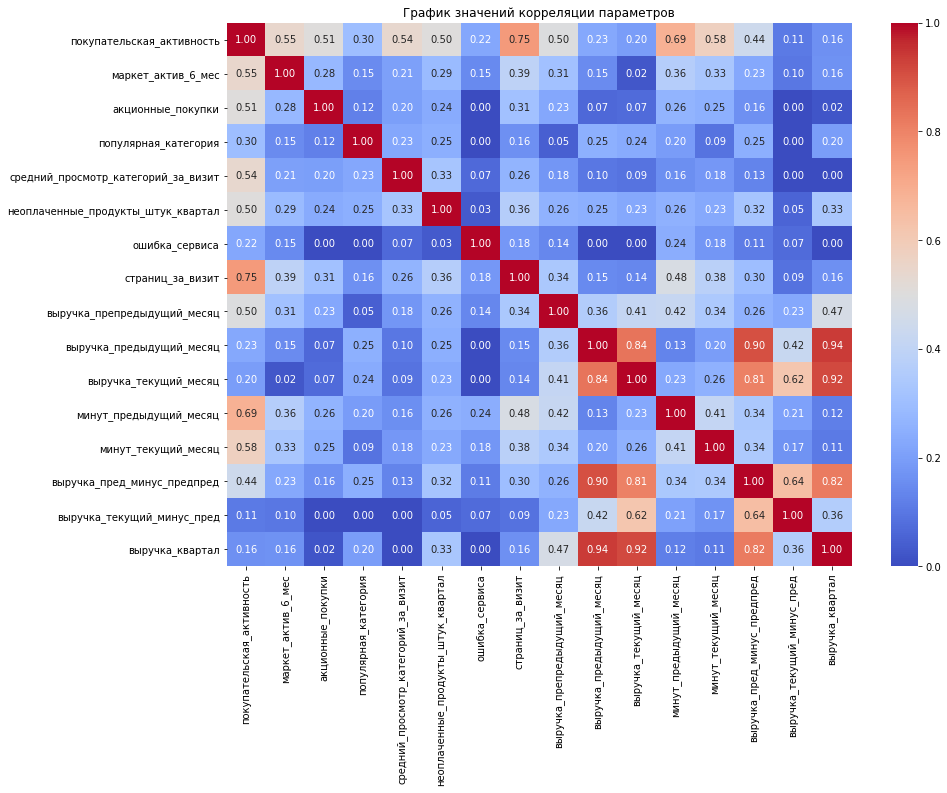

In [56]:
plt.figure(figsize = (14, 10))
fig = sns.heatmap(df_final.phik_matrix(), vmin=0, vmax=1, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('График значений корреляции параметров')
plt.show()

interval columns not set, guessing: ['маркет_актив_6_мес', 'акционные_покупки', 'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит', 'выручка_препредыдущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц', 'выручка_пред_минус_предпред']


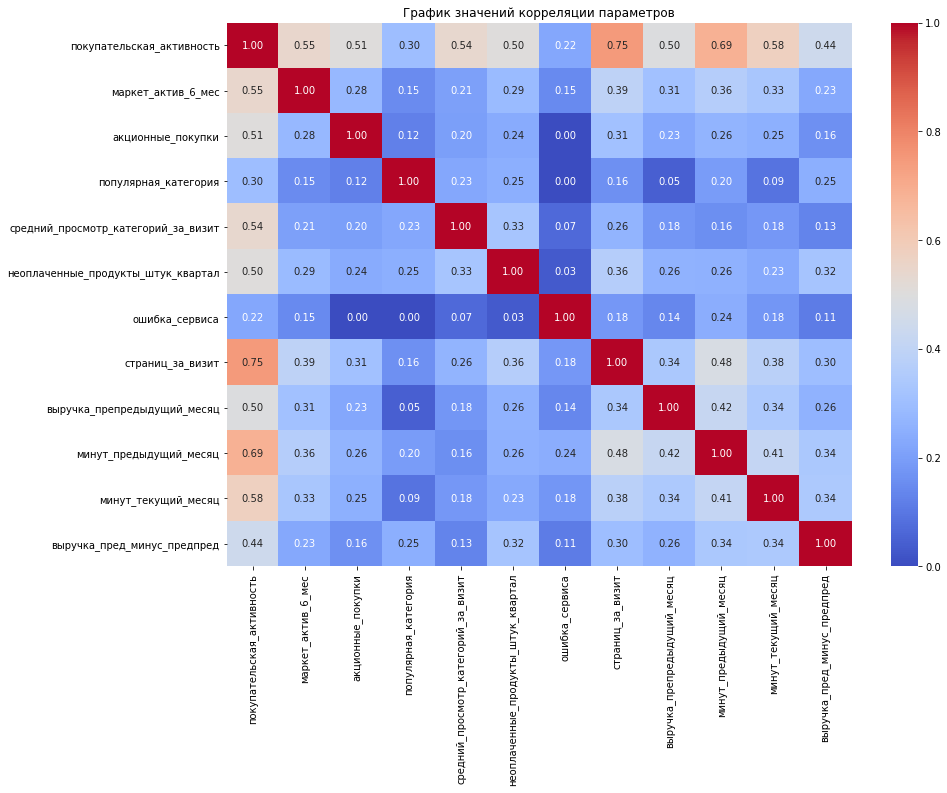

In [57]:
df_final = df_final.drop(['выручка_предыдущий_месяц', 'выручка_текущий_месяц',
                          'выручка_текущий_минус_пред', 'выручка_квартал'], axis=1)

plt.figure(figsize = (14, 10))
fig = sns.heatmap(df_final.phik_matrix(), vmin=0, vmax=1, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('График значений корреляции параметров')
plt.show()

Выполнен корреляционный анализ параметров. Из-за низкой корреляции с целевым параметром 'покупательская_активность' были убраны параметры 'тип_сервиса', 'разрешить_сообщать', 'маркет_актив_тек_мес', 'длительность'. Для уменьшения зависимости между входными параметрами по выручке был оставдел параметр 'выручка_препредыдущий_месяц', т.к. он имеет большее значение коэффициента корреляции с цлевым параметром, и добавлен параметр 'выручка_пред_минус_предпред' для учёта разницы значений выручки между месяцами.

## Использование пайплайнов

In [58]:
df_final['покупательская_активность'] = df_final['покупательская_активность'].map({'прежний_уровень':0, 'снизилась':1})

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    df_final.drop(['покупательская_активность'], axis=1),
    df_final['покупательская_активность'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = df_final['покупательская_активность'])

X_train.shape, X_test.shape

((972, 11), (325, 11))

In [60]:
X_train.sample(3)

,маркет_актив_6_мес,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_препредыдущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,выручка_пред_минус_предпред
id,,,,,,,,,,,
215732,3.5,0.98,косметика_и_аксесуары,3,6,4,3,4955.0,16,11,855.0
216110,5.1,0.24,товары_для_детей,2,5,6,12,4489.0,18,12,240.0
216273,5.7,0.14,товары_для_детей,6,1,4,9,4766.0,17,14,-1291.0


In [61]:
ohe_columns = ['популярная_категория']
num_columns = X_train.select_dtypes(include='number').columns.tolist()

In [62]:
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [63]:
param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
        # словарь для модели SVC()
    {
        'models': [SVC(probability=True, random_state=RANDOM_STATE)],
        'models__kernel': ['rbf','sigmoid', 'linear'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

In [64]:
start = time.time()
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train)

print(f'Время выбора и обучения модели: {(time.time() - start):.3f} секунд')
print()
print('Лучшая модель и её параметры:\n', randomized_search.best_estimator_)
print()
print ('Метрика лучшей модели на кросс валидационной выборке:', randomized_search.best_score_)

Время выбора и обучения модели: 1.948 секунд

Лучшая модель и её параметры:
 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['популярная_категория']),
                                                 ('num', MinMaxScaler(),
                                             

In [65]:
y_test_pred = randomized_search.predict(X_test)
print(f'Метрика f1_score на тестовой выборке: {f1_score(y_test, y_test_pred)}')

Метрика f1_score на тестовой выборке: 0.8157894736842105


In [66]:
fpr, tpr, thresholds = roc_curve(y_test, randomized_search.decision_function(X_test))
roc_auc = auc(fpr, tpr)
print(f'Метрика roc_auc на тестовой выборке: {roc_auc}')

Метрика roc_auc на тестовой выборке: 0.9160648371047986


In [67]:
y_test_pred = randomized_search.predict_proba(X_test)[:,1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Метрика ROC-AUC на тестовой выборке: 0.9160648371047986


С использованием паплайнов и перебором 4 моделей KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression(), SVC() с перебором значений их параметров и 2 методов масштабирования данных StandardScaler(), MinMaxScaler() была выбрана модель SVC с параметром kernel='linear' и метод масштабирования MinMaxScaler().

Т.к. целевой признак распределён неравномерно, для выбора модели была выбрана метрика ROC-AUC. Её значение на валидационной выборке 0.903, на тестовой - 0.916, значит модель достаточно обучилась (имеет высокий процент предсказания) и не переобучилась (оценка на тренировочной выборке не превышает значения оценки тестовой выборки).

## Анализ важности признаков

In [68]:
X_train_new = pipe_final.named_steps['preprocessor'].fit_transform(X_train)
X_train_new.shape

(972, 15)

In [69]:
X_test_new = pipe_final.named_steps['preprocessor'].transform(X_test)
X_test_new.shape

(325, 15)

In [70]:
X_train_df = pd.DataFrame(X_train_new,
                          columns = [x.split('__')[-1] for x in pipe_final.named_steps['preprocessor'].get_feature_names_out()])    
X_test_df = pd.DataFrame(X_test_new,
                         columns = [x.split('__')[-1] for x in pipe_final.named_steps['preprocessor'].get_feature_names_out()]) 
X_train_df.head()

,популярная_категория_косметика_и_аксесуары,популярная_категория_кухонная_посуда,популярная_категория_мелкая_бытовая_техника_и_электроника,популярная_категория_техника_для_красоты_и_здоровья,популярная_категория_товары_для_детей,маркет_актив_6_мес,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_препредыдущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,выручка_пред_минус_предпред
0,0.0,0.0,0.0,0.0,1.0,0.578947,0.034091,0.4,0.2,0.777778,0.421053,0.743131,0.833333,0.526316,0.530743
1,0.0,1.0,0.0,0.0,0.0,0.456140,0.931818,0.4,0.7,0.888889,0.263158,0.364217,0.388889,0.315789,0.667609
2,0.0,0.0,0.0,0.0,0.0,0.578947,0.193182,0.6,0.2,0.555556,0.263158,0.705431,0.833333,0.421053,0.480202
3,0.0,0.0,1.0,0.0,0.0,0.561404,0.159091,0.4,0.3,0.555556,0.421053,0.430032,0.277778,0.421053,0.741392
4,0.0,0.0,1.0,0.0,0.0,0.543860,0.943182,0.4,0.1,0.222222,0.263158,0.499681,0.166667,0.105263,0.586449


Т.к. kernel='linear' у подобранной SVC модели, то использую LinearExplainer для shap:

In [71]:
explainer = shap.LinearExplainer(randomized_search.best_estimator_.named_steps['models'],
                                 X_train_df)
shap_values = explainer(X_test_df)

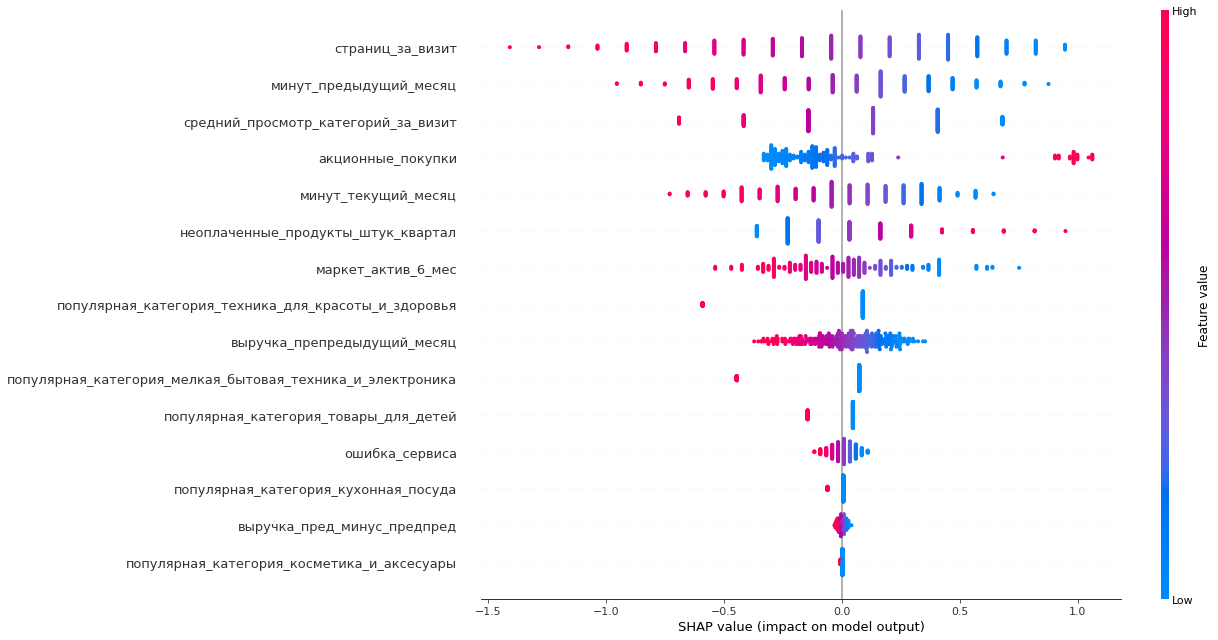

In [72]:
shap.summary_plot(shap_values, X_test_new, plot_size=(18, 9))

Был построен график значимости признаков со значениями Шэпли. Выводы по графику:
* мало значимы для модели признаки:
    - "ошибка_сервиса"
    - разница выручки от покупателя между предыдущим и предпредыдущим месяцами
    - популярные категории "косметика и аксесуары" и "кухонная посуда" менее значимы, чем "техника для красоты и здоровья" и "товары для детей"
* признаки сильнее всего влияют на целевой признак: 
    - чем большие значения прамтеров "страниц за визит", "минут_предыдущий_месяц", "минут_текущий_месяц", "средний_просмотр_категорий_за_визит", тем меньше вероятность снижения покупательской активности. 
    - чем больше доля акционных покупок и больше неоплаченных продуктов, тем больше вероятнрость снижения покупательской активности
* как можно использовать эти наблюдения при моделировании и принятии бизнес-решений:
    - добавленный признак разницы выручек можно убрать из входных признаков, т.к. его значение практически не влияет на принятие решения модели
    - рассылка клиентам информации об интересных ему товарах может удержать выручку, т.к. чем больше клиент просматривает страниц и дольше находится на сайте, тем больше вероятность покупки; для удержания прежней выручки клиент должен покупать не только акционные товары.

## Сегментация покупателей

Для анализа выделю группу клиентов с высокой вероятностью снижения покупательской активности и наиболее высокой прибыльностью, т.к. при снижении покупательской активности в данной группе прибыль будет уменьшаться сильнее.

In [73]:
df_final = df_final.join(df_money)
df_final.head()

,покупательская_активность,маркет_актив_6_мес,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_препредыдущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,выручка_пред_минус_предпред,Прибыль
id,,,,,,,,,,,,,
215349,1,4.4,0.75,товары_для_детей,4,4,2,5,4472.0,12,10,744.0,4.16
215350,1,4.9,0.14,домашний_текстиль,5,2,1,5,4826.0,8,13,631.5,3.13
215351,1,3.2,0.99,товары_для_детей,5,0,6,4,4793.0,11,13,1365.0,4.87
215352,1,5.1,0.94,товары_для_детей,3,2,3,2,4594.0,8,11,1213.5,4.21
215353,1,3.3,0.26,домашний_текстиль,4,1,1,4,5124.0,10,10,-385.5,3.95


In [74]:
df_final.shape

(1297, 13)

In [75]:
df_final['оценки_SVC_модели'] = randomized_search.decision_function(df_final.drop(['покупательская_активность', 'Прибыль'],
                                                                                  axis=1))

In [76]:
df_final['вероятность_принадлежности_к_классу'] = randomized_search.predict_proba(df_final.drop(['покупательская_активность',
                                                                                                 'Прибыль'],
                                                                                                axis=1))[:,1]

In [77]:
df_final['решение_SVC_модели'] = randomized_search.predict(df_final.drop(['покупательская_активность', 'Прибыль'],
                                                                         axis=1))

In [78]:
df_final.sample(5)

,покупательская_активность,маркет_актив_6_мес,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_препредыдущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,выручка_пред_минус_предпред,Прибыль,оценки_SVC_модели,вероятность_принадлежности_к_классу,решение_SVC_модели
id,,,,,,,,,,,,,,,,
216221,0,3.3,0.30,домашний_текстиль,6,5,2,7,4384.0,14,15,1500.0,3.23,-0.480873,0.374985,0
216178,0,3.3,0.18,товары_для_детей,2,2,6,15,5010.0,19,14,552.0,3.98,-1.961923,0.060424,0
215837,1,4.9,0.14,техника_для_красоты_и_здоровья,3,1,6,9,5268.0,15,18,-375.0,5.95,-2.538903,0.025258,0
216596,0,4.1,0.29,домашний_текстиль,6,4,5,10,4882.0,12,19,45.0,4.66,-1.565182,0.101477,0
215663,1,2.6,0.28,товары_для_детей,1,2,5,4,4291.0,5,6,1012.5,3.69,2.384566,0.979812,1


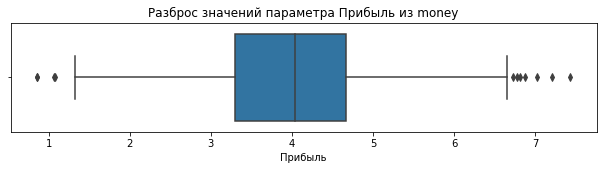

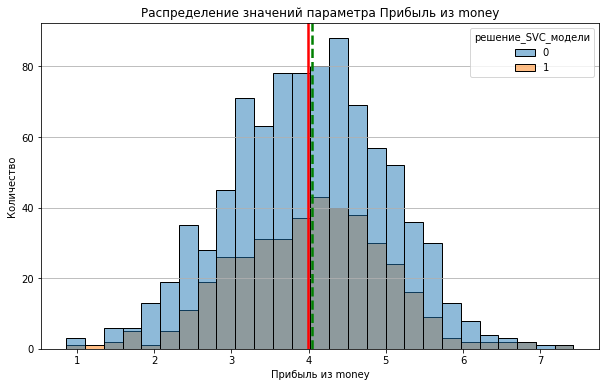

In [79]:
plot_box_hist(df_final['Прибыль'], 'Прибыль из money', df_final, 'решение_SVC_модели');

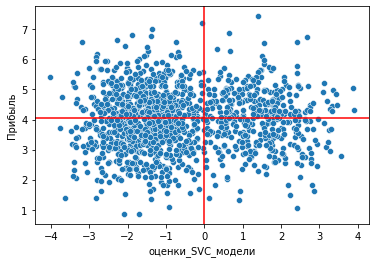

In [80]:
sns.scatterplot(x=df_final['оценки_SVC_модели'],
                y=df_final['Прибыль'])
plt.axvline(0, c='red', ls='-', lw=1.5)
plt.axhline(df_final['Прибыль'].median(), c='red', ls='-', lw=1.5)
plt.show()

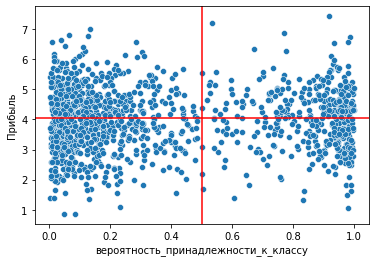

In [81]:
sns.scatterplot(x=df_final['вероятность_принадлежности_к_классу'],
                y=df_final['Прибыль'])
plt.axvline(0.5, c='red', ls='-', lw=1.5)
plt.axhline(df_final['Прибыль'].median(), c='red', ls='-', lw=1.5)
plt.show()

In [82]:
df_users_group = df_final[(df_final['Прибыль'] > df_final['Прибыль'].median())
                          & (df_final['вероятность_принадлежности_к_классу'] > 0.5)]
print(df_users_group.shape)
df_users_group.head()

(219, 16)


,покупательская_активность,маркет_актив_6_мес,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_препредыдущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,выручка_пред_минус_предпред,Прибыль,оценки_SVC_модели,вероятность_принадлежности_к_классу,решение_SVC_модели
id,,,,,,,,,,,,,,,,
215349,1,4.4,0.75,товары_для_детей,4,4,2,5,4472.0,12,10,744.0,4.16,1.014368,0.855660,1
215351,1,3.2,0.99,товары_для_детей,5,0,6,4,4793.0,11,13,1365.0,4.87,0.597730,0.757530,1
215352,1,5.1,0.94,товары_для_детей,3,2,3,2,4594.0,8,11,1213.5,4.21,1.778391,0.950390,1
215356,1,4.2,0.14,косметика_и_аксесуары,2,2,1,3,4433.0,6,7,-286.5,4.93,1.716718,0.945737,1
215360,1,3.9,0.35,кухонная_посуда,3,1,4,7,5555.0,9,6,-250.5,4.55,0.316430,0.669816,1


Для анализа выбрана группа пользвателей из 219 человек.

Распределение популярных категорий 
товары_для_детей                        73
косметика_и_аксесуары                   54
домашний_текстиль                       35
кухонная_посуда                         29
техника_для_красоты_и_здоровья          17
мелкая_бытовая_техника_и_электроника    11
Name: популярная_категория, dtype: int64


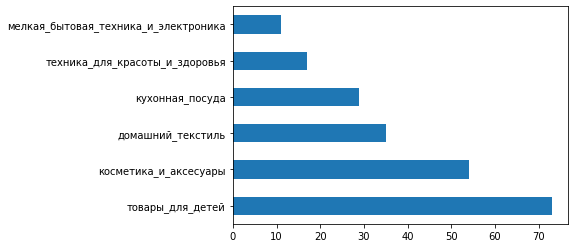

In [83]:
print(f'Распределение популярных категорий \n{df_users_group["популярная_категория"].value_counts()}')
df_users_group['популярная_категория'].value_counts().plot.barh()
plt.show()

Наиболее популярные категории товаров у выбранной группы товары_для_детей и косметика_и_аксесуары, но в группу входят все виды категорий

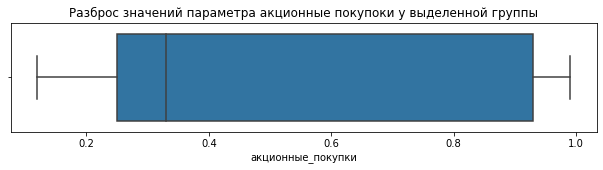

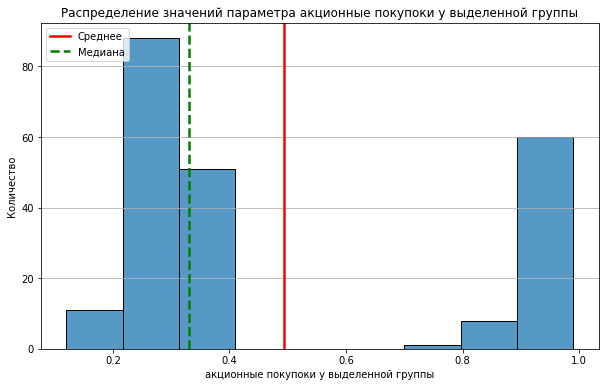

In [84]:
plot_box_hist(df_users_group['акционные_покупки'], 'акционные покупоки у выделенной группы', None, None);

Ввыделенной групе нет преобладания покупок по акциям.

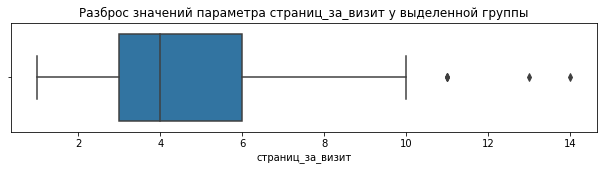

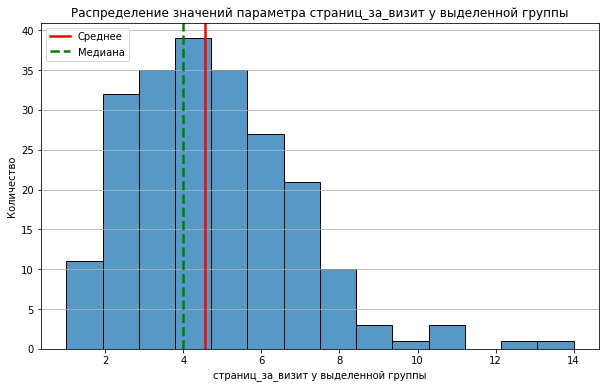

In [85]:
plot_box_hist(df_users_group['страниц_за_визит'], 'страниц_за_визит у выделенной группы', None, None);

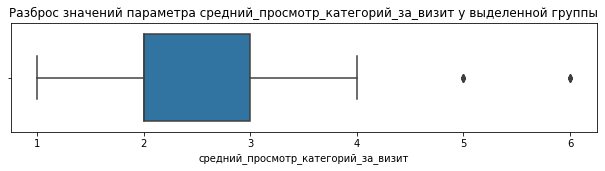

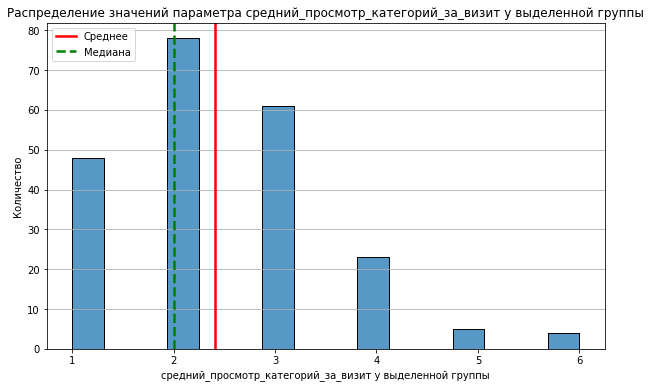

In [86]:
plot_box_hist(df_users_group['средний_просмотр_категорий_за_визит'],
              'средний_просмотр_категорий_за_визит у выделенной группы', None, None);

У выделенной группы в основном низкое количество просмотров категорий за визит.

Для выделенной группы клиентов с высокой вероятностью снижения покупательской активности и наиболее высокой прибыльностью в количестве 219 человек предлагается разослать рекламные предложения с категорией, отличной от их популярной категори, и ссылками на страницы различных товаров (можно сделать дополнительное исследование какие товары из отличных от категорий, популярных у пользователей для рассылки, поулярны у других пользователей). При переходе по ссылкам увеличится количество просмотренных страниц и количество просмотренных категорий, что может повысить выручку, т.к. пользователей могут заинтересовать другие новые для них товары.

## Общий вывод

В рамках задачи необходимо было разработать модель по предсказанию активности клиента в следующие 3 месяца и проанализировать группу клиентов для предложения улучшения по работе с сегментом для увеличения покупательской активности.
Данные были представлены в 4 файлах:
- market_file.csv - таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении;
- market_money.csv - таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом;
- market_time.csv - таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода;
- money.csv - таблица с данными о среднемесячной прибыли покупателя за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.

В ходе работы:
- в рамках предобработки данных были выявлены и устранены неявные дубликаты и опечатки
- в рамках исследовательского анализа данные были изучены, отобраны клиенты с активностью более 3 месяцев, устранена аномалия в значении выручки
- данные из 3 файлов были объеденены в один общий датафрейм 
- был выполнен корреляционный анализ, часть параметров были убраны для устранения зависимостей между входными признаками, часть параметров убраны из-за отсутствия корреляции с целевым признаком, новые параметры разницы выручек между месяцами добавлены и проанализированы
- был создан пайплан для подбора наиболее эффективной (точной) модели с подбором гиперпараметров и выбором метода для нормализации данных, из 4 моделей KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression(), SVC() с перебором значений их параметров и 2 методов масштабирования данных StandardScaler(), MinMaxScaler() была выбрана модель SVC с параметром kernel='linear' и метод масштабирования MinMaxScaler(). Выбор модели осуществлялся при помощи метрики ROC-AUC, значение которой на валидационной выборке составило 0.903, на тестовой - 0.916.
- при помощи SHAP был выполнен анализ важности признаков, определены признаки сильнее всего влияющие на целевой:
    - чем большие значения прамтеров "страниц за визит", "минут_предыдущий_месяц", "минут_текущий_месяц", "средний_просмотр_категорий_за_визит", тем меньше вероятность снижения покупательской активности.
    - чем больше доля акционных покупок и больше неоплаченных продуктов, тем больше вероятнрость снижения покупательской активности

В рамках работы по сегментации покупателей:
- было выполнено предсказание о снижении прибыли обученной моделью для всех пользователей
- была выделена группа клиентов с высокой вероятностью снижения покупательской активности и наиболее высокой прибыльностью в количестве 210 человек
- для выделенной группы был проведён анализ данных
- было выдвинуто предложение по увеличению прибыли для выделенной группы: предлагается разослать рекламные предложения с категориями, отличными от их популярной категори, и ссылками на страницы различных популярных товаров (можно сделать дополнительное исследование какие товары из отличных от категорий, популярных у пользователей для рассылки, поулярны у других пользователей)